# Monthly-Small Timing-Bin Regressions

This notebook is designed to give the clearest possible timing evidence from the cleaned public dataset.

## Design choice

Instead of a Dynamic Factor Model, this notebook uses **timing-bin ANCOVA regressions** in the **monthly-small transfer arm only**. This is a better match to the actual structure of `UCT_FINAL_CLEAN.dta`, which is primarily a baseline-endline file with transfer timing variables rather than a true monthly panel.

## Outcomes

- **Material index**: average of baseline-standardized total assets and food security
- **Psychological well-being**: `psy_index_z`

## Main idea

If material gains appear earlier than psychological gains across timing bins, that supports temporal ordering.

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "Correction" / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT / "advanced-econometrics-project"

DATA_PATH = PROJECT_ROOT / "Correction" / "Data" / "UCT_FINAL_CLEAN.dta"
df = pd.read_stata(DATA_PATH)

print(df.shape)

(2880, 981)


## Sample construction

- keep only the **monthly-small** arm: `treatXmonthlyXsmall == 1`
- work at the individual level so `psy_index_z` stays respondent-specific
- construct a household-style material index using repeated household outcomes attached to each individual row
- use `Dlastend` for timing bins, because it gives the time since the most recent transfer

In [2]:
df_indiv = df[(df["endlinedate"].notna()) & (df["purecontrol"] != 1)].copy()
monthly_small = df_indiv[df_indiv["treatXmonthlyXsmall"] == 1].copy()

monthly_small = monthly_small[[
    "surveyid", "village", "Dlastend",
    "asset_total_ppp0", "asset_total_ppp1",
    "fs_hhfoodindexnew0", "fs_hhfoodindexnew1",
    "psy_index_z0", "psy_index_z1",
]].copy()

def make_timing_bin(x):
    if pd.isna(x):
        return np.nan
    if x < 1:
        return "<1 month"
    if x < 4:
        return "1-4 months"
    if x < 8:
        return "4-8 months"
    return "8+ months"

monthly_small["timing_bin"] = monthly_small["Dlastend"].apply(make_timing_bin)
bin_order = ["<1 month", "1-4 months", "4-8 months", "8+ months"]

for outcome in ["asset_total_ppp", "fs_hhfoodindexnew", "psy_index_z"]:
    base_mean = monthly_small[f"{outcome}0"].mean()
    base_std = monthly_small[f"{outcome}0"].std()
    monthly_small[f"{outcome}0_z"] = (monthly_small[f"{outcome}0"] - base_mean) / base_std
    monthly_small[f"{outcome}1_z"] = (monthly_small[f"{outcome}1"] - base_mean) / base_std

monthly_small["material_index0"] = monthly_small[["asset_total_ppp0_z", "fs_hhfoodindexnew0_z"]].mean(axis=1)
monthly_small["material_index1"] = monthly_small[["asset_total_ppp1_z", "fs_hhfoodindexnew1_z"]].mean(axis=1)

display(monthly_small[["surveyid", "Dlastend", "timing_bin", "material_index0", "material_index1", "psy_index_z0_z", "psy_index_z1_z"]].head())
print(f"Monthly-small individual observations: {len(monthly_small):,}")
print(monthly_small["timing_bin"].value_counts().reindex(bin_order))

,surveyid,Dlastend,timing_bin,material_index0,material_index1,psy_index_z0_z,psy_index_z1_z
8,106979214.0,5.095332,4-8 months,-1.821692,0.846819,-0.737395,0.632459
9,106979214.0,5.095332,4-8 months,-1.821692,0.846819,NaN,NaN
20,107646122.0,6.048652,4-8 months,0.464815,1.165260,NaN,NaN
21,107646122.0,6.048652,4-8 months,0.464815,1.165260,-0.796263,-0.937148
30,107785019.0,4.010520,4-8 months,-1.619666,0.408212,0.572987,NaN


Monthly-small individual observations: 318
timing_bin
<1 month       46.0
1-4 months    160.0
4-8 months     96.0
8+ months       NaN
Name: count, dtype: float64


## Timing-bin regressions

For each outcome, estimate:

$$
Y_{i1} = \alpha + \sum_k \beta_k \mathbf{1}\{\text{timing bin}=k\} + \gamma Y_{i0} + \delta_v + \varepsilon_i
$$

where the omitted category is `<1 month`. This makes later bins easy to interpret relative to the immediate post-transfer period.

In [3]:
reg_df = monthly_small.dropna(subset=["timing_bin", "material_index0", "material_index1", "psy_index_z0_z", "psy_index_z1_z", "village"]).copy()
reg_df["timing_bin"] = pd.Categorical(reg_df["timing_bin"], categories=bin_order, ordered=True)

material_model = smf.ols(
    "material_index1 ~ C(timing_bin, Treatment(reference='<1 month')) + material_index0 + C(village)",
    data=reg_df,
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["village"]})

psych_model = smf.ols(
    "psy_index_z1_z ~ C(timing_bin, Treatment(reference='<1 month')) + psy_index_z0_z + C(village)",
    data=reg_df,
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["village"]})

print(material_model.summary())
print(psych_model.summary())

                            OLS Regression Results                            
Dep. Variable:        material_index1   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     1.863
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.147
Time:                        13:20:06   Log-Likelihood:                -230.00
No. Observations:                 208   AIC:                             572.0
Df Residuals:                     152   BIC:                             758.9
Df Model:                          55                                         
Covariance Type:              cluster                                         
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 56, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 56, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [4]:
def extract_timing_terms(result, model_name):
    rows = []
    for term, coef in result.params.items():
        if "C(timing_bin" not in term:
            continue
        se = result.bse[term]
        pval = result.pvalues[term]
        label = term.split("T.")[-1].rstrip("]")
        rows.append({
            "model": model_name,
            "timing_bin": label,
            "coef": float(coef),
            "std_err": float(se),
            "p_value": float(pval),
            "ci_low": float(coef - 1.96 * se),
            "ci_high": float(coef + 1.96 * se),
        })
    base_row = {
        "model": model_name,
        "timing_bin": "<1 month (ref)",
        "coef": 0.0,
        "std_err": np.nan,
        "p_value": np.nan,
        "ci_low": 0.0,
        "ci_high": 0.0,
    }
    return pd.DataFrame([base_row] + rows)

coef_table = pd.concat([
    extract_timing_terms(material_model, "Material index"),
    extract_timing_terms(psych_model, "Psychological well-being"),
], ignore_index=True)

coef_table["timing_bin"] = pd.Categorical(
    coef_table["timing_bin"],
    categories=["<1 month (ref)", "1-4 months", "4-8 months", "8+ months"],
    ordered=True,
)
coef_table = coef_table.sort_values(["model", "timing_bin"])
display(coef_table)

,model,timing_bin,coef,std_err,p_value,ci_low,ci_high
0,Material index,<1 month (ref),0.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00
1,Material index,1-4 months,-2.482725e-01,2.906479e-01,0.392992,-8.179424e-01,3.213973e-01
2,Material index,4-8 months,-9.489926e-01,7.926380e-01,0.231206,-2.502563e+00,6.045778e-01
3,Material index,8+ months,7.185346e-16,6.042614e-16,0.234396,-4.658178e-16,1.902887e-15
4,Psychological well-being,<1 month (ref),0.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00
5,Psychological well-being,1-4 months,2.272604e-01,2.480225e-01,0.359515,-2.588637e-01,7.133845e-01
6,Psychological well-being,4-8 months,8.684162e-01,3.241853e-01,0.007389,2.330131e-01,1.503819e+00
7,Psychological well-being,8+ months,-2.005502e-15,2.154421e-15,0.351917,-6.228167e-15,2.217163e-15


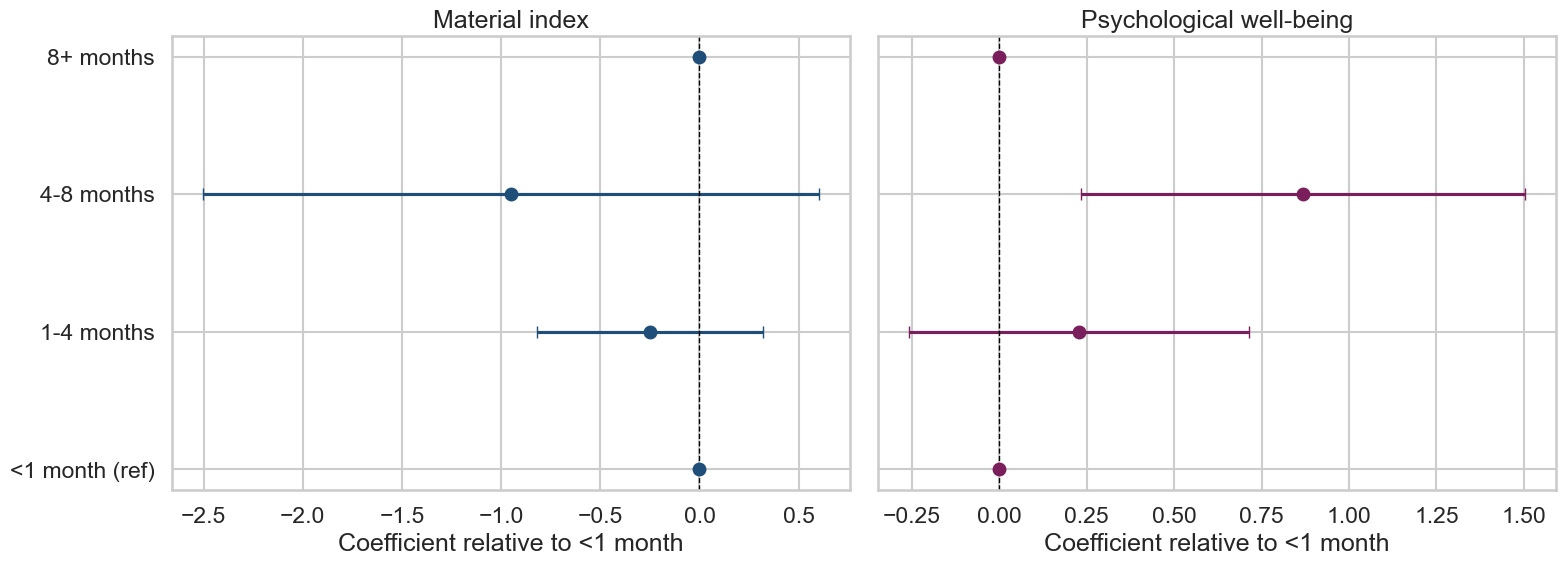

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, model_name in zip(axes, ["Material index", "Psychological well-being"]):
    sub = coef_table[coef_table["model"] == model_name].copy()
    ax.errorbar(
        x=sub["coef"],
        y=np.arange(len(sub)),
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt="o",
        capsize=4,
        color="#1f4e79" if model_name == "Material index" else "#7a1f5c",
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(np.arange(len(sub)))
    ax.set_yticklabels(sub["timing_bin"])
    ax.set_title(model_name)
    ax.set_xlabel("Coefficient relative to <1 month")

plt.tight_layout()
plt.show()

In [6]:
report_table = coef_table[["model", "timing_bin", "coef", "std_err", "p_value", "ci_low", "ci_high"]].copy()
report_table = report_table.rename(columns={
    "model": "Outcome",
    "timing_bin": "Timing bin",
    "coef": "Coefficient",
    "std_err": "Std. Err.",
    "p_value": "P-value",
    "ci_low": "95% CI low",
    "ci_high": "95% CI high",
})

display(report_table)
print(report_table.to_string(index=False))

,Outcome,Timing bin,Coefficient,Std. Err.,P-value,95% CI low,95% CI high
0,Material index,<1 month (ref),0.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00
1,Material index,1-4 months,-2.482725e-01,2.906479e-01,0.392992,-8.179424e-01,3.213973e-01
2,Material index,4-8 months,-9.489926e-01,7.926380e-01,0.231206,-2.502563e+00,6.045778e-01
3,Material index,8+ months,7.185346e-16,6.042614e-16,0.234396,-4.658178e-16,1.902887e-15
4,Psychological well-being,<1 month (ref),0.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00
5,Psychological well-being,1-4 months,2.272604e-01,2.480225e-01,0.359515,-2.588637e-01,7.133845e-01
6,Psychological well-being,4-8 months,8.684162e-01,3.241853e-01,0.007389,2.330131e-01,1.503819e+00
7,Psychological well-being,8+ months,-2.005502e-15,2.154421e-15,0.351917,-6.228167e-15,2.217163e-15


                 Outcome     Timing bin   Coefficient    Std. Err.  P-value    95% CI low  95% CI high
          Material index <1 month (ref)  0.000000e+00          NaN      NaN  0.000000e+00 0.000000e+00
          Material index     1-4 months -2.482725e-01 2.906479e-01 0.392992 -8.179424e-01 3.213973e-01
          Material index     4-8 months -9.489926e-01 7.926380e-01 0.231206 -2.502563e+00 6.045778e-01
          Material index      8+ months  7.185346e-16 6.042614e-16 0.234396 -4.658178e-16 1.902887e-15
Psychological well-being <1 month (ref)  0.000000e+00          NaN      NaN  0.000000e+00 0.000000e+00
Psychological well-being     1-4 months  2.272604e-01 2.480225e-01 0.359515 -2.588637e-01 7.133845e-01
Psychological well-being     4-8 months  8.684162e-01 3.241853e-01 0.007389  2.330131e-01 1.503819e+00
Psychological well-being      8+ months -2.005502e-15 2.154421e-15 0.351917 -6.228167e-15 2.217163e-15
